# RKKY interaction between magnetic impurities
Let us now see how two magnetic impurities in a metal talk to each other, with
`rkky.rkky_map()`. A local moment polarizes the conduction electrons around it, and a second
moment at some distance feels that polarization, so that the two end up coupled by an effective
exchange $J(\vec r)$ that depends on their separation: this is the RKKY
(Ruderman-Kittel-Kasuya-Yosida) interaction. At lowest order in the coupling to the electrons it
is given by the static spin response of the host, and `rkky.rkky_map(h,n=...,mode="LR")`
computes it from linear response between a reference site and every site within `n` unit cells
of it, so that the result is resolved in real space. It returns one row per site, with the
columns $(x,y,z,J)$.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import rkky

### Graphene at half filling
In a bipartite lattice at half filling the sign of the coupling is fixed by the sublattice: it
is ferromagnetic between two sites of the same sublattice and antiferromagnetic between sites of
opposite sublattices. The map shows $J$ around a reference site of the honeycomb lattice, the
black cross; since the coupling decays quickly with distance, the color scale is the cube root
of $J$, which keeps the sign and makes the distant sites visible.

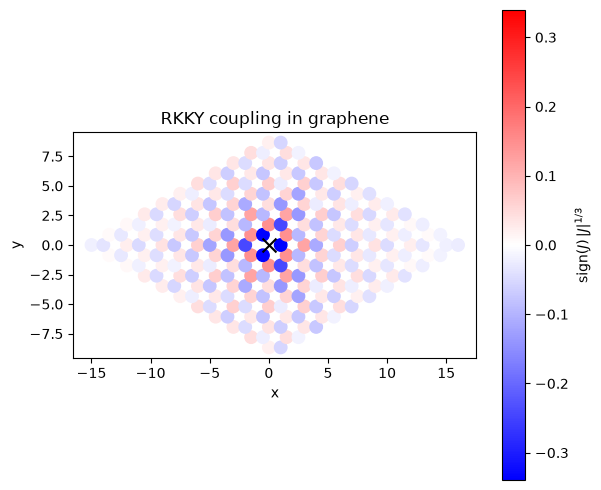

In [2]:
g = geometry.honeycomb_lattice() # honeycomb lattice
h = g.get_hamiltonian() # half-filled Hamiltonian
m = rkky.rkky_map(h,n=5,mode="LR",nk=30) # RKKY around the reference site
x,y,J = m[:,0],m[:,1],m[:,3] # positions and coupling

c = np.sign(J)*np.abs(J)**(1./3.) # cube root, keeping the sign
v = np.max(np.abs(c))
plt.figure(figsize=(6,5))
plt.scatter(x,y,c=c,cmap="bwr",vmin=-v,vmax=v,s=80)
plt.colorbar(label=r"sign$(J)\,|J|^{1/3}$")
plt.scatter([0.],[0.],marker="x",c="black",s=100) # reference site
plt.gca().set_aspect("equal")
plt.xlabel("x") ; plt.ylabel("y")
plt.title("RKKY coupling in graphene")
plt.tight_layout()
plt.show()

Every site of the sublattice of the reference site has one color and every site of the other
sublattice the opposite one, all the way out, which is the sublattice rule above.

### Friedel oscillations in a doped metal
Away from half filling there is no sublattice rule: the coupling oscillates in sign with the
distance, with a period set by the Fermi wavevector, and its pattern follows the shape of the
Fermi surface. We take a square lattice with the Fermi energy moved into the lower half of the
band with an onsite energy, and compare the map with the coupling along the $x$ axis.

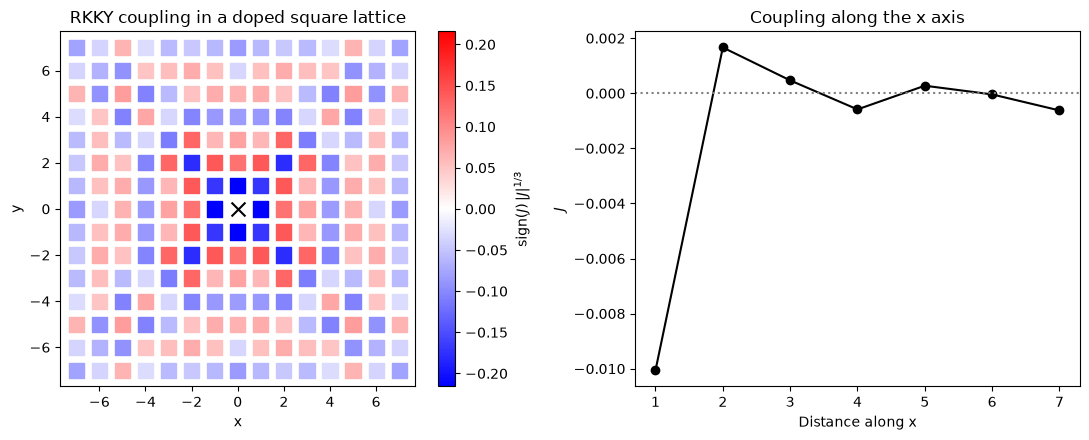

In [3]:
g = geometry.square_lattice() # square lattice
h = g.get_hamiltonian() # first-neighbor hopping
h.add_onsite(1.0) # move the Fermi energy away from half filling
m = rkky.rkky_map(h,n=7,mode="LR",nk=40) # RKKY around the reference site
x,y,J = m[:,0],m[:,1],m[:,3] # positions and coupling

c = np.sign(J)*np.abs(J)**(1./3.) # cube root, keeping the sign
v = np.max(np.abs(c))
fig,axs = plt.subplots(1,2,figsize=(11,4.5))
sc = axs[0].scatter(x,y,c=c,cmap="bwr",vmin=-v,vmax=v,s=120,marker="s")
fig.colorbar(sc,ax=axs[0],label=r"sign$(J)\,|J|^{1/3}$")
axs[0].scatter([0.],[0.],marker="x",c="black",s=100) # reference site
axs[0].set_aspect("equal") ; axs[0].set_xlabel("x") ; axs[0].set_ylabel("y")
axs[0].set_title("RKKY coupling in a doped square lattice")
axis = (np.abs(y)<1e-6) & (x>0) # sites along the x axis
axs[1].plot(x[axis],J[axis],marker="o",c="black")
axs[1].axhline(0.,c="gray",ls=":")
axs[1].set_xlabel("Distance along x") ; axs[1].set_ylabel("$J$")
axs[1].set_title("Coupling along the x axis")
plt.tight_layout()
plt.show()

The coupling now changes sign every few sites, and the pattern is not isotropic: the square
Fermi surface of the lattice leaves its imprint on the map, with the oscillations along the axes
different from those along the diagonals. The value of `nk` sets how far the map can be trusted,
since the Brillouin-zone sum can only resolve separations smaller than the size of the k-mesh.